# 09 — Cellpose 3 vs Cellpose 4: side-by-side

Reads the eight result files written by notebooks 01–08 and draws the comparison: count scatter plots
per dataset, total training + tuning cost per model, and the accuracy metrics.

Every model was trained and tuned by mycol's own workers at that generation's default settings, on
the saved session's own train/test split. See any training notebook for the full protocol.

**Run notebooks 01–08 first** — this one only reads their cached JSON.

In [1]:
import json, sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import common

DATASETS = ["cs1", "bright_ecoli", "s_aureus", "mcount"]
MODELS = ["cp3", "cp4"]
LABEL = {"cp3": "Cellpose 3", "cp4": "Cellpose 4"}
COL = {"cp3": "#0072B2", "cp4": "#D55E00"}

R = {}
missing = []
for ds in DATASETS:
    for m in MODELS:
        f = common.OUT_DIR / f"{ds}_{m}.json"
        if f.exists():
            R[(ds, m)] = json.loads(f.read_text())
        else:
            missing.append(f.name)
print(f"loaded {len(R)} of {len(DATASETS)*len(MODELS)} results")
if missing:
    print("missing (run the corresponding notebook):", ", ".join(missing))

loaded 8 of 8 results


In [2]:
# --- summary table ---
rows = []
for ds in DATASETS:
    for m in MODELS:
        r = R.get((ds, m))
        if not r:
            continue
        rows.append({
            "dataset": ds, "model": LABEL[m],
            "train/test": f"{r['n_train']}/{r['n_test']}",
            "train s": r["train_seconds"], "tune s": r["tune_seconds"],
            "total min": (r["train_seconds"] + r["tune_seconds"]) / 60,
            "R2": r["r2"], "MAE": r["mae"], "MAPE %": r["mape"],
            "IoU": r["mean_iou_matched"], "AP@0.5": r["ap50"], "F1@0.5": r["f1_50"],
            "infer s/img": r["infer_seconds_per_image"],
        })
try:
    import pandas as pd
    table = pd.DataFrame(rows).set_index(["dataset", "model"]).round(3)
    display(table)
except ImportError:
    for r in rows:
        print(r)

train/test   train s    tune s  total min     R2  \
dataset      model                                                         
cs1          Cellpose 3    521/131  2141.696   353.716     41.590  0.989   
             Cellpose 4    521/131  1655.143  3424.548     84.662  0.979   
bright_ecoli Cellpose 3      56/14   241.246  1058.437     21.661  0.964   
             Cellpose 4      56/14  1017.921  3896.148     81.901  0.988   
s_aureus     Cellpose 3       34/9   156.279   657.106     13.556  0.997   
             Cellpose 4       34/9   986.997  3419.680     73.445  0.994   
mcount       Cellpose 3      40/10   164.214   326.053      8.171  0.965   
             Cellpose 4      40/10   993.556  3523.013     75.276  0.979   

                            MAE  MAPE %    IoU  AP@0.5  F1@0.5  infer s/img  
dataset      model                                                           
cs1          Cellpose 3   1.069   3.761  0.853   0.947   0.970        0.322  
             Cellpose 4   1.160   4.069  0.843   0.935   0.964        2.384  
bright_ecoli Cellpose 3  29.714  13.200  0.737   0.821   0.907        1.548  
             Cellpose 4  15.929   5.514  0.802   0.888   0.921        5.060  
s_aureus     Cellpose 3   6.889   3.109  0.900   0.945   0.968        1.127  
             Cellpose 4   9.333   3.597  0.883   0.944   0.968        4.859  
mcount       Cellpose 3   2.200   3.942  0.879   0.925   0.959        0.451  
             Cellpose 4   1.500   2.971  0.851   0.950   0.975        4.872

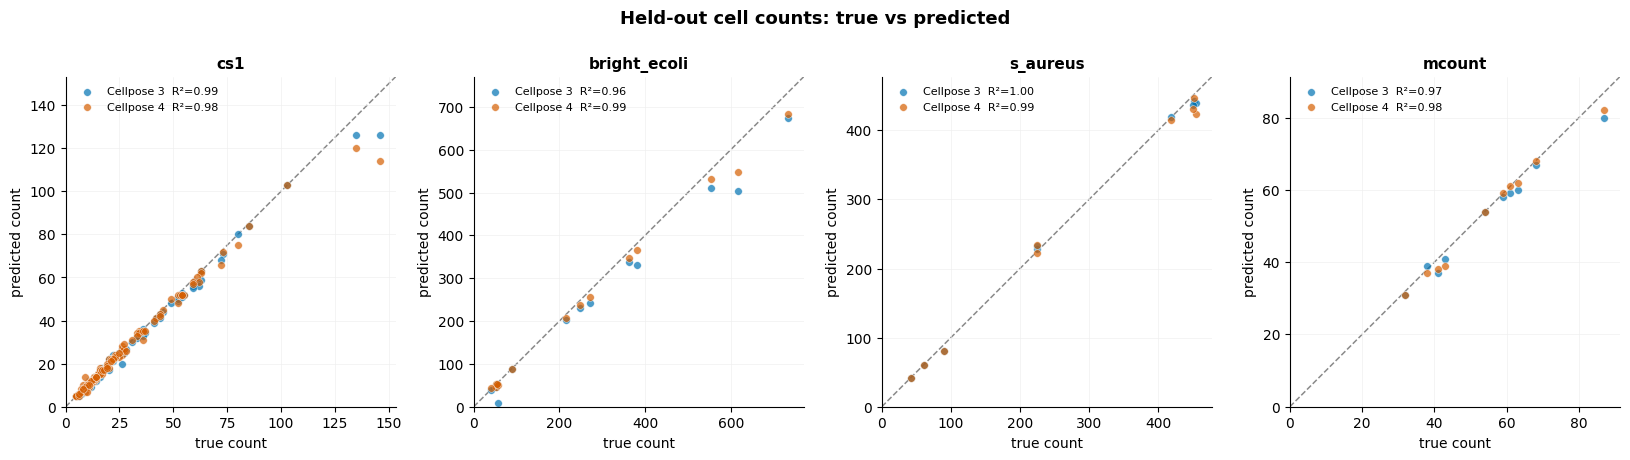

In [3]:
# --- count scatter: one panel per dataset, both models overlaid ---
fig, axes = plt.subplots(1, len(DATASETS), figsize=(4.1 * len(DATASETS), 4.3))
for ax, ds in zip(np.atleast_1d(axes), DATASETS):
    lim = 1
    for m in MODELS:
        r = R.get((ds, m))
        if not r:
            continue
        t, p = np.array(r["true_counts"]), np.array(r["pred_counts"])
        lim = max(lim, t.max(), p.max())
        ax.scatter(t, p, s=30, alpha=0.7, color=COL[m], edgecolors="white", linewidths=0.4,
                   label=f"{LABEL[m]}  R²={r['r2']:.2f}")
    lim *= 1.05
    ax.plot([0, lim], [0, lim], ls="--", lw=1.1, color="#8a8a8a", zorder=0)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim); ax.set_aspect("equal")
    ax.set_title(ds, fontsize=11, fontweight="bold")
    ax.set_xlabel("true count"); ax.set_ylabel("predicted count")
    ax.legend(frameon=False, fontsize=8, loc="upper left")
    ax.grid(True, lw=0.4, color="#ededed"); ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
fig.suptitle("Held-out cell counts: true vs predicted", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(common.REPO / "cp3_vs_cp4" / "counts_scatter.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

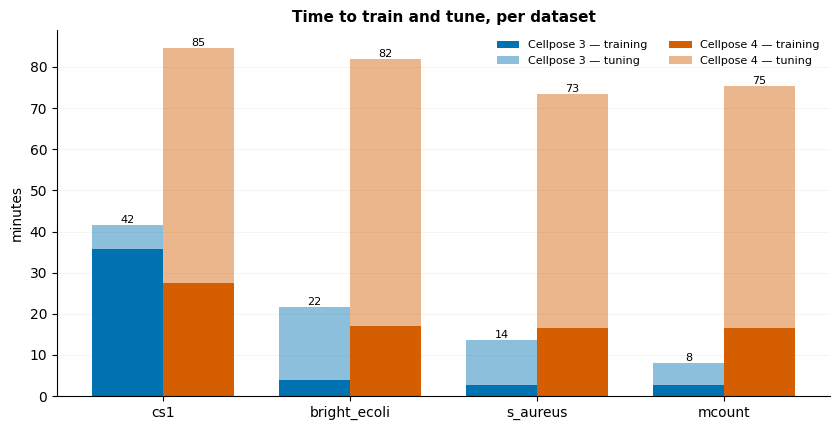

In [4]:
# --- cost: training + hyperparameter tuning, stacked ---
x = np.arange(len(DATASETS)); w = 0.38
fig, ax = plt.subplots(figsize=(8.5, 4.4))
for i, m in enumerate(MODELS):
    tr = [R[(d, m)]["train_seconds"] / 60 if (d, m) in R else 0 for d in DATASETS]
    tu = [R[(d, m)]["tune_seconds"] / 60 if (d, m) in R else 0 for d in DATASETS]
    off = (i - 0.5) * w
    ax.bar(x + off, tr, w, color=COL[m], label=f"{LABEL[m]} — training")
    ax.bar(x + off, tu, w, bottom=tr, color=COL[m], alpha=0.45,
           label=f"{LABEL[m]} — tuning")
    for xi, (a, b) in zip(x + off, zip(tr, tu)):
        if a + b:
            ax.text(xi, a + b, f"{a+b:.0f}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x, DATASETS); ax.set_ylabel("minutes")
ax.set_title("Time to train and tune, per dataset", fontsize=11, fontweight="bold")
ax.legend(frameon=False, fontsize=8, ncol=2)
ax.grid(True, axis="y", lw=0.4, color="#ededed"); ax.set_axisbelow(True)
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)
fig.tight_layout()
fig.savefig(common.REPO / "cp3_vs_cp4" / "time_comparison.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

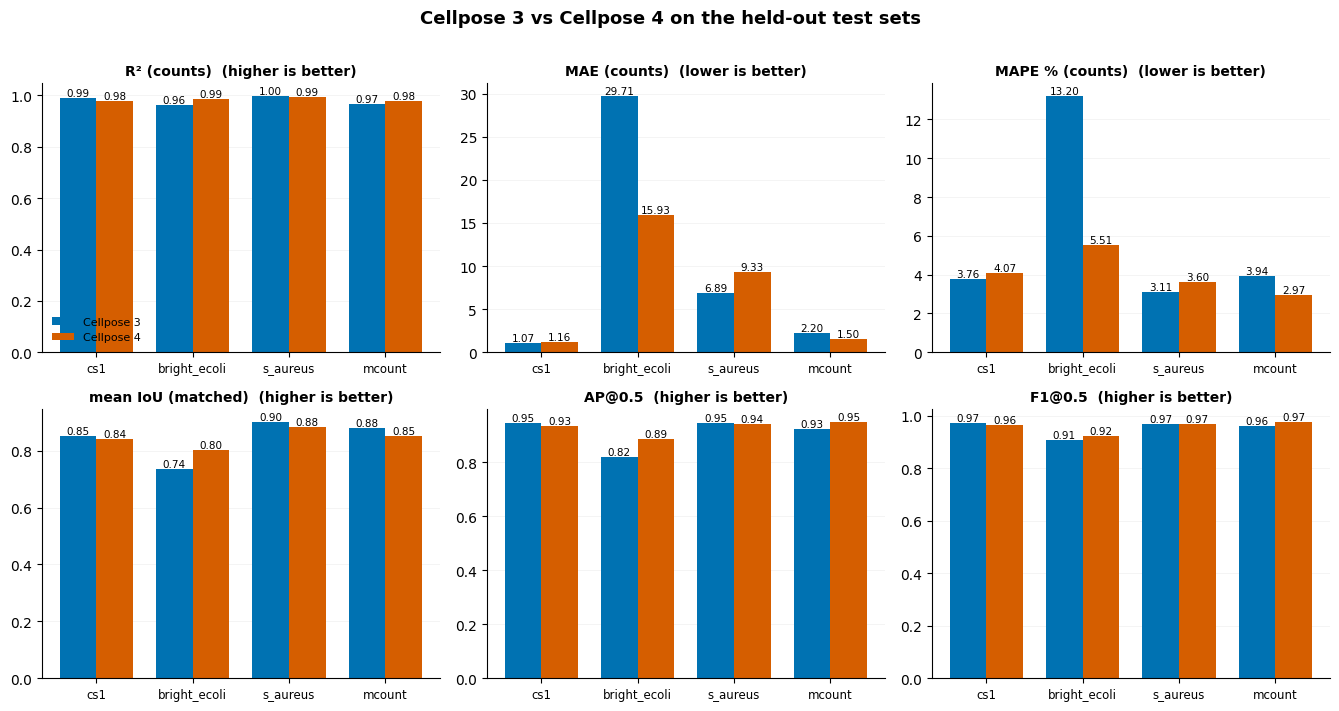

In [5]:
# --- accuracy metrics side by side ---
METRICS = [("r2", "R² (counts)", True), ("mae", "MAE (counts)", False),
           ("mape", "MAPE % (counts)", False), ("mean_iou_matched", "mean IoU (matched)", True),
           ("ap50", "AP@0.5", True), ("f1_50", "F1@0.5", True)]
fig, axes = plt.subplots(2, 3, figsize=(13.5, 7))
x = np.arange(len(DATASETS)); w = 0.38
for ax, (key, title, higher_better) in zip(axes.ravel(), METRICS):
    for i, m in enumerate(MODELS):
        vals = [R[(d, m)][key] if (d, m) in R else np.nan for d in DATASETS]
        ax.bar(x + (i - 0.5) * w, vals, w, color=COL[m], label=LABEL[m])
        for xi, v in zip(x + (i - 0.5) * w, vals):
            if np.isfinite(v):
                ax.text(xi, v, f"{v:.2f}", ha="center",
                        va="bottom" if v >= 0 else "top", fontsize=7.5)
    ax.set_xticks(x, DATASETS, fontsize=8.5)
    ax.set_title(f"{title}  ({'higher' if higher_better else 'lower'} is better)",
                 fontsize=10, fontweight="bold")
    ax.grid(True, axis="y", lw=0.4, color="#ededed"); ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
axes.ravel()[0].legend(frameon=False, fontsize=8)
fig.suptitle("Cellpose 3 vs Cellpose 4 on the held-out test sets", fontsize=13,
             fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(common.REPO / "cp3_vs_cp4" / "metrics_comparison.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

## Where the time actually goes

Training, tuning and inference scale very differently between the two generations. Everything below
is derived from the recorded timings — no models are re-run.

In [6]:
# --- tuning decomposed: it is just inference, repeated ---
# validation_worker tunes on min(40, n_train) images and runs n_trials of them, so
# tune_seconds should be approximately trials x images x (seconds per inference).
rows = []
for ds in DATASETS:
    for m in MODELS:
        r = R.get((ds, m))
        if not r:
            continue
        n_tune = min(40, r["n_train"])
        per_trial = r["tune_seconds"] / r["n_trials_run"]
        rows.append({"dataset": ds, "model": LABEL[m], "trials": r["n_trials_run"],
                     "tune images": n_tune, "tune s": round(r["tune_seconds"]),
                     "s/trial": round(per_trial, 1),
                     "s/img in sweep": round(per_trial / n_tune, 2),
                     "s/img on test": round(r["infer_seconds_per_image"], 2)})
try:
    import pandas as pd
    display(pd.DataFrame(rows).set_index(["dataset", "model"]))
except ImportError:
    [print(x) for x in rows]
print()
print("The last two columns agree closely: tuning carries no hidden overhead - it is")
print("n_trials x n_images inferences. Trial counts fall below 20 when Optuna repeats a")
print("combination, which the worker serves from its cache.")

trials  tune images  tune s  s/trial  s/img in sweep  \
dataset      model                                                              
cs1          Cellpose 3      19           40     354     18.6            0.47   
             Cellpose 4      20           40    3425    171.2            4.28   
bright_ecoli Cellpose 3      17           40    1058     62.3            1.56   
             Cellpose 4      19           40    3896    205.1            5.13   
s_aureus     Cellpose 3      18           34     657     36.5            1.07   
             Cellpose 4      20           34    3420    171.0            5.03   
mcount       Cellpose 3      19           40     326     17.2            0.43   
             Cellpose 4      19           40    3523    185.4            4.64   

                         s/img on test  
dataset      model                      
cs1          Cellpose 3           0.32  
             Cellpose 4           2.38  
bright_ecoli Cellpose 3           1.55  
             Cellpose 4           5.06  
s_aureus     Cellpose 3           1.13  
             Cellpose 4           4.86  
mcount       Cellpose 3           0.45  
             Cellpose 4           4.87


The last two columns agree closely: tuning carries no hidden overhead - it is
n_trials x n_images inferences. Trial counts fall below 20 when Optuna repeats a
combination, which the worker serves from its cache.


In [7]:
# --- what Optuna chose, and what it cost ---
# `diameter` is the only tuned parameter that changes what the network sees: Cellpose-SAM
# rescales by 30/diameter, so a larger value means fewer pixels and quadratically less
# transformer work. The thresholds are pure post-processing.
print(f"{'dataset':14}{'model':13}{'diameter':>10}{'niter':>7}{'min_size':>10}{'s/img':>8}")
for ds in DATASETS:
    for m in MODELS:
        r = R.get((ds, m))
        if not r:
            continue
        bp = r["best_params"]
        print(f"{ds:14}{LABEL[m]:13}{str(bp.get('diameter', 'n/a')):>10}"
              f"{bp['niter']:>7}{bp['min_size']:>10}{r['infer_seconds_per_image']:>8.2f}")

dataset       model          diameter  niter  min_size   s/img
cs1           Cellpose 3          n/a    500         0    0.32
cs1           Cellpose 4           41   2000        90    2.38
bright_ecoli  Cellpose 3          n/a      0        10    1.55
bright_ecoli  Cellpose 4         None   2000        20    5.06
s_aureus      Cellpose 3          n/a      0        10    1.13
s_aureus      Cellpose 4         None    200         0    4.86
mcount        Cellpose 3          n/a      0        36    0.45
mcount        Cellpose 4         None    200         0    4.87


In [8]:
# --- pipeline share, ratios, and what a flow-cached sweep would save ---
tot = {m: sum(R[(d, m)]["train_seconds"] + R[(d, m)]["tune_seconds"]
              for d in DATASETS if (d, m) in R) for m in MODELS}
tun = {m: sum(R[(d, m)]["tune_seconds"] for d in DATASETS if (d, m) in R) for m in MODELS}
trn = {m: sum(R[(d, m)]["train_seconds"] for d in DATASETS if (d, m) in R) for m in MODELS}
inf = {m: sum(R[(d, m)]["infer_seconds_per_image"] for d in DATASETS if (d, m) in R) for m in MODELS}
for m in MODELS:
    print(f"{LABEL[m]:12} total {tot[m]/60:6.0f} min   training {trn[m]/60:5.0f}   "
          f"tuning {tun[m]/60:5.0f} ({100*tun[m]/tot[m]:.0f}% of pipeline)")
print()
print(f"cp4/cp3  training {trn['cp4']/trn['cp3']:.2f}x   tuning {tun['cp4']/tun['cp3']:.2f}x   "
      f"inference {inf['cp4']/inf['cp3']:.2f}x")

# Only `diameter` changes the network input, so one forward pass per distinct diameter
# candidate would serve every trial. Cellpose 4 searches <= 5 candidates.
DIAM_CANDIDATES = 5
proj = tun["cp4"] * DIAM_CANDIDATES / 20
print()
print("If the sweep cached network flows instead of recomputing them each trial,")
print(f"Cellpose 4 tuning would need <= {DIAM_CANDIDATES} forward passes rather than 20:")
print(f"  tuning  {tun['cp4']/60:.0f} min -> ~{proj/60:.0f} min")
print(f"  total   {tot['cp4']/60:.0f} min -> ~{(tot['cp4']-tun['cp4']+proj)/60:.0f} min "
      f"(vs {tot['cp3']/60:.0f} min for Cellpose 3)")

Cellpose 3   total     85 min   training    45   tuning    40 (47% of pipeline)
Cellpose 4   total    315 min   training    78   tuning   238 (75% of pipeline)

cp4/cp3  training 1.72x   tuning 5.95x   inference 4.98x

If the sweep cached network flows instead of recomputing them each trial,
Cellpose 4 tuning would need <= 5 forward passes rather than 20:
  tuning  238 min -> ~59 min
  total   315 min -> ~137 min (vs 85 min for Cellpose 3)


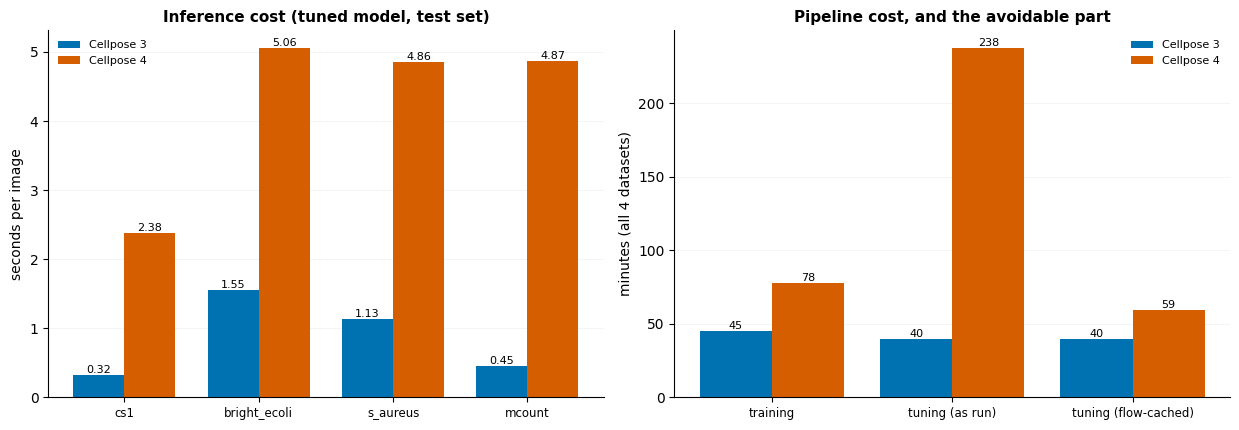

In [9]:
# --- timing figure ---
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
x = np.arange(len(DATASETS)); w = 0.38

for i, m in enumerate(MODELS):                      # inference cost per image
    v = [R[(d, m)]["infer_seconds_per_image"] if (d, m) in R else np.nan for d in DATASETS]
    axes[0].bar(x + (i - 0.5) * w, v, w, color=COL[m], label=LABEL[m])
    for xi, vi in zip(x + (i - 0.5) * w, v):
        if np.isfinite(vi):
            axes[0].text(xi, vi, f"{vi:.2f}", ha="center", va="bottom", fontsize=8)
axes[0].set_xticks(x, DATASETS, fontsize=8.5); axes[0].set_ylabel("seconds per image")
axes[0].set_title("Inference cost (tuned model, test set)", fontsize=11, fontweight="bold")
axes[0].legend(frameon=False, fontsize=8)

labels = ["training", "tuning (as run)", "tuning (flow-cached)"]
vals3 = [trn["cp3"]/60, tun["cp3"]/60, tun["cp3"]/60]
vals4 = [trn["cp4"]/60, tun["cp4"]/60, proj/60]
xb = np.arange(3)
axes[1].bar(xb - 0.2, vals3, 0.4, color=COL["cp3"], label="Cellpose 3")
axes[1].bar(xb + 0.2, vals4, 0.4, color=COL["cp4"], label="Cellpose 4")
for xi, v in list(zip(xb - 0.2, vals3)) + list(zip(xb + 0.2, vals4)):
    axes[1].text(xi, v, f"{v:.0f}", ha="center", va="bottom", fontsize=8)
axes[1].set_xticks(xb, labels, fontsize=8.5); axes[1].set_ylabel("minutes (all 4 datasets)")
axes[1].set_title("Pipeline cost, and the avoidable part", fontsize=11, fontweight="bold")
axes[1].legend(frameon=False, fontsize=8)
for ax in axes:
    ax.grid(True, axis="y", lw=0.4, color="#ededed"); ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
fig.tight_layout()
fig.savefig(common.REPO / "cp3_vs_cp4" / "timing_breakdown.png", dpi=150, bbox_inches="tight",
            facecolor="white")
plt.show()

### Reading the timings

- **Tuning is not a separate cost — it is inference, 20 x ~40 times.** The "s/img in sweep" and
  "s/img on test" columns agree, so there is no hidden overhead in the Optuna loop itself.
- **Only `diameter` changes what the network sees.** `cellprob`, `flow_threshold`, `niter` and
  `min_size` are post-processing of the same network output, yet every trial recomputes the full
  forward pass. Caching flows per diameter candidate would cut Cellpose 4's tuning several-fold; the
  cell above projects it.
- **Watch where Optuna chose a real diameter.** It is the one case that runs at roughly half the
  per-image cost of the others, which is the downscaling lever paying off — the search found it
  unprompted on the dataset with the smallest cells.
- **Training is the closest of the three.** Cellpose 4's `nimg_per_epoch=8` fixes it at 800 gradient
  steps regardless of dataset size, so it does not grow with the training set the way Cellpose 3's
  does.

## Reading this

- **Every model is scored on its dataset's own held-out test split**, rebuilt from the saved session,
  so the two models on a given row saw identical training and test images.
- **Cost is training + tuning wall-clock on this machine.** Cellpose 4's tuning is dominated by
  inference, so its bar is mostly the Optuna sweep rather than the fine-tune itself.
- **The count metrics (R², MAE, MAPE) and the mask metrics (IoU, AP, F1) can disagree.** A model can
  get totals right while placing boundaries poorly, or vice versa. Which matters depends on whether
  the app is being used to count or to measure morphology.
- **Test sets are small for three of the four datasets** (14, 9 and 10 images). Treat single-dataset
  differences cautiously and look for a consistent direction across all four.